**Disclaimer:** The following code is inspired by https://github.com/paulaoak/proximal-ipla/tree/main/image_deblurring.

*Note: A bug present in the $\mathrm{MYPGD}$ algorithm has been fixed in the below.* 

# Imports

In [1]:
import numpy as np
import scipy.ndimage
import imageio.v3 as imageio
import matplotlib.pyplot as plt
import pickle
import random

import numpy as np
from tqdm import tqdm
from prox_tv import tv1_2d
from skimage.metrics import structural_similarity as ssim
from joblib import Parallel, delayed

import scipy.sparse as sp

from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

from matplotlib.patches import Circle


## Utility Functions

In [ ]:
### Reproducibility ###

def set_seed(seed: int):
    np.random.seed(seed)
    random.seed(seed)


### Blurring ###

# Note: `generate_blur_matrix` is taken from: https://github.com/paulaoak/proximal-ipla/tree/main/image_deblurring

def generate_blur_matrix(n1, n2, patch_size=10):
    """Generates a blurring matrix H that uniformly averages over a patch_size x patch_size neighborhood."""
    size = n1 * n2
    H = sp.lil_matrix((size, size)) # This is a structure for constructing sparse matrices incrementally.
    pad = patch_size // 2
    
    for i in range(n1):
        for j in range(n2):
            row_idx = i * n2 + j
            weights = []
            indices = []
            
            for di in range(-pad, pad + 1):
                for dj in range(-pad, pad + 1):
                    ni, nj = i + di, j + dj
                    if 0 <= ni < n1 and 0 <= nj < n2:
                        col_idx = ni * n2 + nj
                        indices.append(col_idx)
                        weights.append(1)
            
            weights = np.array(weights) / np.sum(weights)
            H[row_idx, indices] = weights
    
    return H.tocsr()


### Total Variation Helpers ###

# Note: `discrete_gradient` and `total_variation` is taken from: https://github.com/paulaoak/proximal-ipla/tree/main/image_deblurring

def discrete_gradient(n1, n2):
    """Constructs the discrete gradient operator for total variation."""
    size = n1 * n2
    Dx = sp.lil_matrix((size, size))
    Dy = sp.lil_matrix((size, size))
    
    for i in range(n1):
        for j in range(n2):
            idx = i * n2 + j
            if i < n1 - 1:
                Dx[idx, idx] = -1
                Dx[idx, idx + n2] = 1
            if j < n2 - 1:
                Dy[idx, idx] = -1
                Dy[idx, idx + 1] = 1
    
    return Dx.tocsr(), Dy.tocsr()


def total_variation(x, Dx, Dy):
    """
    x shape: (n1, n2, N)
    returns per-particle TV, shape (N,)
    """
    x_flat = x.reshape(-1, x.shape[2])
    grad_x = Dx @ x_flat
    grad_y = Dy @ x_flat
    return np.sum(np.sqrt(grad_x**2 + grad_y**2), axis=0)


def total_variation_particles(w: np.ndarray, Dx, Dy) -> np.ndarray:
    return total_variation(w, Dx, Dy)


def get_ssim_data_range(original: np.ndarray) -> float:
    dr = float(original.max() - original.min())
    if dr <= 1e-12:
        dr = 1.0
    return dr


### prox_{lambda exp(theta) TV} ###

# def prox_particles(
#     w: np.ndarray,
#     theta: float,
#     lambdaaa: float,
#     method_tv: str = "dr",
# ) -> np.ndarray:
#     """
#     Apply prox_{lambda exp(theta) TV} to each particle image separately.
#     """
#     prox_w = np.empty_like(w)
#     for i in range(w.shape[2]):
#         prox_w[:, :, i] = tv1_2d(
#             w[:, :, i],
#             np.exp(theta) * lambdaaa,
#             method=method_tv,
#         )
#     return prox_w

def prox_particles(
    w: np.ndarray,
    theta: float,
    lambdaaa: float,
    method_tv: str = "dr",
    n_jobs: int = -1,
) -> np.ndarray:
    """
    Apply prox_{lambda exp(theta) TV} to each particle image separately,
    in parallel across particles.
    """
    prox_weight = np.exp(theta) * lambdaaa

    prox_list = Parallel(n_jobs=n_jobs)(
        delayed(tv1_2d)(w[:, :, i], prox_weight, method=method_tv)
        for i in range(w.shape[2])
    )

    return np.stack(prox_list, axis=2)


### Weight Helpers ###

def softmax_log_weights(log_w: np.ndarray) -> np.ndarray:
    m = np.max(log_w)
    w = np.exp(log_w - m)
    return w / np.sum(w)


def effective_sample_size_from_logw(log_w: np.ndarray) -> float:
    w = softmax_log_weights(log_w)
    return 1.0 / np.sum(w ** 2)


def systematic_resample(weights: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    N = len(weights)
    positions = (rng.random() + np.arange(N)) / N
    cumsum = np.cumsum(weights)
    idx = np.zeros(N, dtype=np.int64)

    i, j = 0, 0
    while i < N:
        if positions[i] < cumsum[j]:
            idx[i] = j
            i += 1
        else:
            j += 1
            
    return idx


### Reconstruction Metrics ###

def weighted_mean_image(w: np.ndarray, log_w: np.ndarray) -> np.ndarray:
    weights = softmax_log_weights(log_w)
    return np.tensordot(w, weights, axes=([2], [0]))


def mean_image_unweighted(w: np.ndarray) -> np.ndarray:
    return np.mean(w, axis=2)


def reconstruction_metrics_weighted(
    w: np.ndarray,
    log_w: np.ndarray,
    original: np.ndarray,
):
    """
    For SOSMC methods with importance weights.
    """
    weights = softmax_log_weights(log_w)
    x_hat = weighted_mean_image(w, log_w)

    original_reshape = original[:, :, None]
    dr = get_ssim_data_range(original)

    # Mean-image metrics
    mse_mean_image = float(np.mean((x_hat - original) ** 2))
    nmse_mean_image = float(np.sum((x_hat - original) ** 2) / np.sum(original ** 2))
    ssim_mean_image = float(ssim(original, x_hat, data_range=dr))

    # Particle-cloud metrics
    sqerr = (w - original_reshape) ** 2
    mse_particles = np.mean(sqerr, axis=(0, 1))
    nmse_particles = np.sum(sqerr, axis=(0, 1)) / np.sum(original ** 2)
    ssim_particles = np.array([
        ssim(original, w[:, :, i], data_range=dr)
        for i in range(w.shape[2])
    ])

    mse_cloud = float(np.sum(weights * mse_particles))
    nmse_cloud = float(np.sum(weights * nmse_particles))
    ssim_cloud = float(np.sum(weights * ssim_particles))

    return {
        "x_hat": x_hat,
        "mse_mean_image": mse_mean_image,
        "nmse_mean_image": nmse_mean_image,
        "ssim_mean_image": ssim_mean_image,
        "mse": mse_cloud,
        "nmse": nmse_cloud,
        "ssim": ssim_cloud,
        "mse_particles": mse_particles,
        "nmse_particles": nmse_particles,
        "ssim_particles": ssim_particles,
    }


def reconstruction_metrics_unweighted(
    w: np.ndarray,
    original: np.ndarray,
):
    """
    For MYPGD / equally weighted particle methods.
    """
    N = w.shape[2]
    weights = np.ones(N, dtype=float) / N
    x_hat = mean_image_unweighted(w)

    original_reshape = original[:, :, None]
    dr = get_ssim_data_range(original)

    # Mean-image metrics
    mse_mean_image = float(np.mean((x_hat - original) ** 2))
    nmse_mean_image = float(np.sum((x_hat - original) ** 2) / np.sum(original ** 2))
    ssim_mean_image = float(ssim(original, x_hat, data_range=dr))

    # Particle-cloud metrics
    sqerr = (w - original_reshape) ** 2
    mse_particles = np.mean(sqerr, axis=(0, 1))
    nmse_particles = np.sum(sqerr, axis=(0, 1)) / np.sum(original ** 2)
    ssim_particles = np.array([
        ssim(original, w[:, :, i], data_range=dr)
        for i in range(N)
    ])

    mse_cloud = float(np.sum(weights * mse_particles))
    nmse_cloud = float(np.sum(weights * nmse_particles))
    ssim_cloud = float(np.sum(weights * ssim_particles))

    return {
        "x_hat": x_hat,
        "mse_mean_image": mse_mean_image,
        "nmse_mean_image": nmse_mean_image,
        "ssim_mean_image": ssim_mean_image,
        "mse": mse_cloud,
        "nmse": nmse_cloud,
        "ssim": ssim_cloud,
        "mse_particles": mse_particles,
        "nmse_particles": nmse_particles,
        "ssim_particles": ssim_particles,
    }

## Utility Functions - Plotting

In [ ]:
### Experiment Results ###

def plot_results(
    results_dict,
    keys,
    labels_map=None,
    styles_map=None,
    figsize=(7, 4),
    show=True,
):
    """
    Generic plotting helper.
    """
    if labels_map is None:
        labels_map = {}

    if styles_map is None:
        styles_map = {}

    for key in keys:
        available = {
            method_name: out
            for method_name, out in results_dict.items()
            if isinstance(out, dict) and key in out and out[key] is not None
        }

        if not available:
            print(f"[plot_results] Skipping '{key}' because no method contains it!")
            continue

        plt.figure(figsize=figsize)

        for method_name, out in available.items():
            values = np.asarray(out[key]).squeeze()

            if values.ndim == 0 or values.size == 0:
                print(f"[plot_results] Skipping '{key}' for '{method_name}' (not plottable).")
                continue

            style = styles_map.get(method_name, {})
            plt.plot(values, label=method_name, **style)

        plt.xlabel("Iterations")
        plt.ylabel(labels_map.get(key, key))
        plt.title(labels_map.get(key, key))
        plt.legend()
        plt.tight_layout()

        if show:
            plt.show()


### Experiment Results (Improved) ###

METHOD_COLORS = {
    "MYPGD": "#003f5c",
    "SOSMC-MYULA": "#bc5090",
}

LABEL_MAP = {
    "MYPGD": "MYPGD",
    "SOSMC-MYULA": "SOSMC-MYULA",
}

LINESTYLE_MAP = {
    "MYPGD": "-",
    "SOSMC-MYULA": "-",
}


def plot_deblurring_metrics_three_panel(
    results,
    methods=("MYPGD", "SOSMC-MYULA"),
    figsize=(14.5, 5.0),
    dpi=300,
    linewidth=None,
    alpha=0.98,
    title=None,
    save_path=None,
    theta_reference=np.log(0.03),
    base_height=3.8,
    legend_y=0.98,
    axes_top=0.76,
):
    """
    Generic plotting helper - Improved.
    """
    scale = figsize[1] / base_height

    title_fontsize = 11 * scale
    label_fontsize = 10 * scale
    tick_fontsize = 8.5 * scale
    legend_fontsize = 10 * scale
    annotation_fontsize = 8.5 * scale

    if linewidth is None:
        linewidth = 2.5 * scale

    methods_present = [m for m in methods if m in results]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=figsize,
        dpi=dpi,
        sharex=True,
    )

    # Reserve some space for the top legend!
    fig.subplots_adjust(
        top=axes_top,
        bottom=0.16,
        left=0.07,
        right=0.99,
        wspace=0.30,
    )

    ax_theta, ax_mse, ax_ssim = axes

    metric_specs = [
        ("theta", ax_theta, r"$\theta$", "Theta estimate"),
        ("mse", ax_mse, "MSE", "Particle-cloud MSE"),
        ("ssim", ax_ssim, "SSIM", "Particle-cloud SSIM"),
    ]

    for method in methods_present:
        out = results[method]
        color = METHOD_COLORS.get(method, "C0")
        linestyle = LINESTYLE_MAP.get(method, "-")
        label = LABEL_MAP.get(method, method)

        for key, ax, ylabel, panel_title in metric_specs:
            if key not in out or out[key] is None:
                continue

            y = np.asarray(out[key]).squeeze()

            if y.ndim == 0 or y.size == 0:
                continue

            x = np.arange(1, len(y) + 1)

            ax.plot(
                x,
                y,
                color=color,
                lw=linewidth,
                linestyle=linestyle,
                alpha=alpha,
                solid_capstyle="round",
                label=label,
            )

    # Horizontal reference line on theta panel
    ax_theta.axhline(
        y=theta_reference,
        color="black",
        linestyle="--",
        linewidth=max(1.0 * scale, 1.0),
        alpha=0.9,
        label=r"$\log(0.03)$",
    )

    ax_theta.text(
        0.10,
        0.85,
        r"$\log(0.03)$",
        transform=ax_theta.transAxes,
        fontsize=annotation_fontsize,
        color="black",
        ha="left",
        va="bottom",
    )

    for ax in axes:
        ax.grid(True, alpha=0.20, linewidth=0.8 * scale)

        ax.set_xlabel("Iteration", fontsize=label_fontsize)
        ax.tick_params(axis="both", labelsize=tick_fontsize)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    ax_theta.set_title("Theta estimate", fontsize=title_fontsize)
    ax_theta.set_ylabel(r"$\theta$", fontsize=label_fontsize)

    ax_mse.set_title("Particle-cloud MSE", fontsize=title_fontsize)
    ax_mse.set_ylabel("MSE", fontsize=label_fontsize)

    ax_ssim.set_title("Particle-cloud SSIM", fontsize=title_fontsize)
    ax_ssim.set_ylabel("SSIM", fontsize=label_fontsize)
    ax_ssim.set_ylim(-0.05, 1.02)

    handles = [
        Line2D(
            [0],
            [0],
            color=METHOD_COLORS.get(m, "C0"),
            lw=2.8 * scale,
            linestyle=LINESTYLE_MAP.get(m, "-"),
            label=LABEL_MAP.get(m, m),
        )
        for m in methods_present
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, legend_y),
        ncol=max(len(handles), 1),
        frameon=False,
        fontsize=legend_fontsize,
        handlelength=2.8,
        columnspacing=1.8,
    )

    if title:
        fig.suptitle(title, y=1.08, fontsize=13 * scale)

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
            pad_inches=0.05,
        )

    plt.show()


### Original Image vs Blurred Image vs MYPGD Image vs SOSMC_MYULA ###

def plot_reconstruction_ordered(
    image,
    blurred_image,
    out_mypgd,
    out_sosmc_myula,
    figsize=(12, 3),
    dpi=220,
    cmap_img="gray",
    save_path=None,
):
    """
    Plots the `image`, next to the `blurred_image`, next to the `out_mypgd`, next to the `out_sosmc_myula`.
    """
    img_vmin = min(
        image.min(),
        blurred_image.min(),
        out_mypgd["x_hat"].min(),
        out_sosmc_myula["x_hat"].min(),
    )
    img_vmax = max(
        image.max(),
        blurred_image.max(),
        out_mypgd["x_hat"].max(),
        out_sosmc_myula["x_hat"].max(),
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=figsize,
        dpi=dpi,
        squeeze=False,
        gridspec_kw={
            "wspace": 0.04,
        },
    )

    axes = axes[0]

    panels = [
        (image, "Original Image"),
        (blurred_image, "Blurred Image"),
        (out_mypgd["x_hat"], "MYPGD"),
        (out_sosmc_myula["x_hat"], "SOSMC-MYULA"),
    ]

    for ax, (img, title) in zip(axes, panels):
        ax.imshow(img, cmap=cmap_img, vmin=img_vmin, vmax=img_vmax)
        ax.set_title(title, fontsize=11, pad=4)
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.subplots_adjust(
        left=0.02,
        right=0.98,
        top=0.88,
        bottom=0.04,
        wspace=0.04,
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", pad_inches=0.02)

    plt.show()


### Final Particle Cloud Comparison (with optional zooms)

def _add_zoom_inspect(
    ax, 
    image, 
    src_center, src_radius, 
    dst_center, dst_radius,
    cmap="gray", 
    vmin=None, vmax=None,
    edge_color="red",
    linewidth=1.2, 
    interpolation="bilinear",
):
    """
    Overlays a circular magnified inspection of `image`.
    """
    fig = ax.figure
    H, W = image.shape[:2]

    cx, cy = src_center
    cx_d, cy_d = dst_center

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    ax.add_patch(Circle(
        src_center, src_radius,
        fill=False, 
        edgecolor=edge_color, 
        linewidth=linewidth,
        zorder=10, 
        clip_on=False,
    ))

    x0 = int(np.floor(cx - src_radius))
    x1 = int(np.ceil(cx + src_radius))
    y0 = int(np.floor(cy - src_radius))
    y1 = int(np.ceil(cy + src_radius))
    x0c, x1c = max(0, x0), min(W, x1)
    y0c, y1c = max(0, y0), min(H, y1)
    crop = image[y0c:y1c, x0c:x1c]
    if crop.size == 0:
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        return

    inv_fig  = fig.transFigure.inverted()
    dst_disp = ax.transData.transform((cx_d, cy_d))
    edge_disp = ax.transData.transform((cx_d + dst_radius, cy_d))
    r_disp = abs(edge_disp[0] - dst_disp[0])

    left_fig,  bottom_fig = inv_fig.transform(
        (dst_disp[0] - r_disp, dst_disp[1] - r_disp)
    )
    right_fig, top_fig = inv_fig.transform(
        (dst_disp[0] + r_disp, dst_disp[1] + r_disp)
    )
    w_fig = right_fig - left_fig
    h_fig = top_fig   - bottom_fig

    zoom_ax = fig.add_axes([left_fig, bottom_fig, w_fig, h_fig], zorder=20)
    zoom_ax.imshow(
        crop, 
        cmap=cmap, 
        vmin=vmin, vmax=vmax,
        interpolation=interpolation, 
        origin="upper",
    )
    zoom_ax.set_axis_off()

    clip_circle = Circle((0.5, 0.5), 0.5, transform=zoom_ax.transAxes)
    for artist in zoom_ax.get_images():
        artist.set_clip_path(clip_circle)

    zoom_ax.add_patch(
        Circle(
            (0.5, 0.5), 
            0.5, 
            transform=zoom_ax.transAxes,
            fill=False, 
            edgecolor=edge_color, 
            linewidth=linewidth,
            zorder=30, 
            clip_on=False,
        )
    )

    dx, dy = cx_d - cx, cy_d - cy
    dist = float(np.hypot(dx, dy))
    if dist > src_radius + dst_radius:
        ux, uy = dx / dist, dy / dist
        p1 = (cx   + ux * src_radius, cy   + uy * src_radius)
        p2 = (cx_d - ux * dst_radius, cy_d - uy * dst_radius)
        p1f = inv_fig.transform(ax.transData.transform(p1))
        p2f = inv_fig.transform(ax.transData.transform(p2))
        fig.add_artist(Line2D(
            [p1f[0], p2f[0]], 
            [p1f[1], p2f[1]],
            transform=fig.transFigure, 
            color=edge_color,
            linewidth=linewidth, 
            zorder=25, 
            clip_on=False,
        ))

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


def _resolve_per_col(value, c, ncols, default):
    """
    Returns per-column value.
    """
    if value is None:
        return default
    
    if isinstance(value, dict):
        if c in value:
            return value[c]
        
        neg = c - ncols
        if neg in value:
            return value[neg]
        return default
    
    return value


def plot_particle_cloud_comparison(
    results,
    methods=("MYPGD", "SOSMC-MYULA"),
    particle_indices=(0, 1, 2, 3, 4, 5, 6, 7),
    figsize=(13, 3.6),
    dpi=200,
    cmap="gray",
    use_global_range=True,
    save_path=None,
    inspect=False,
    inspect_src_center=None,
    inspect_src_radius=None,
    inspect_dst_center=None,
    inspect_dst_radius=None,
    inspect_rows=None,
    inspect_columns=(-1,),
    inspect_edge_color="red",
    inspect_linewidth=1.2,
    inspect_interpolation="bilinear",
):
    """
    Plots the particle comparison, with optional zooms overlayed.
    """
    methods_present = [m for m in methods if m in results]
    particle_indices = list(particle_indices)

    if not methods_present:
        raise ValueError("No requested methods found in results.")

    displayed = []
    for method in methods_present:
        samples = results[method]["samples"]
        for idx in particle_indices:
            if idx < samples.shape[2]:
                displayed.append(samples[:, :, idx])

    if not displayed:
        raise ValueError("No valid particle indices found.")

    if use_global_range:
        vmin = min(img.min() for img in displayed)
        vmax = max(img.max() for img in displayed)
    else:
        vmin = vmax = None

    nrows = len(methods_present)
    ncols = len(particle_indices)
    H, W = displayed[0].shape[:2]

    if inspect:
        default_src_radius = max(5.0, 0.06 * min(H, W))
        default_dst_radius = 0.22 * min(H, W)
        default_src_center = (W * 0.5, H * 0.40)
        default_dst_center = (W - default_dst_radius - 2,
                              default_dst_radius + 2)

    inspect_cols_set = {c if c >= 0 else ncols + c for c in inspect_columns}
    if inspect_rows is None:
        inspect_rows_set = set(range(nrows))
    else:
        inspect_rows_set = {r if r >= 0 else nrows + r for r in inspect_rows}

    fig, axes = plt.subplots(
        nrows, ncols, figsize=figsize, dpi=dpi, squeeze=False,
        gridspec_kw={"wspace": 0.02, "hspace": 0.04},
    )

    plt.subplots_adjust(
        left=0.045, right=0.995, top=0.90, bottom=0.06,
        wspace=0.02, hspace=0.02,
    )

    # Draw all Particle Clouds
    for r, method in enumerate(methods_present):
        samples = results[method]["samples"]
        for c, idx in enumerate(particle_indices):
            ax = axes[r, c]
            if idx >= samples.shape[2]:
                ax.axis("off")
                continue
            img = samples[:, :, idx]
            ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])
            if r == 0:
                ax.set_title(f"Particle {idx}", fontsize=10, pad=4)
            if c == 0:
                ax.set_ylabel(method, fontsize=12, color="black", labelpad=6)
            for spine in ax.spines.values():
                spine.set_visible(False)

    # Add zooms
    if inspect:
        fig.canvas.draw()

        for r, method in enumerate(methods_present):
            if r not in inspect_rows_set:
                continue
            samples = results[method]["samples"]
            for c, idx in enumerate(particle_indices):
                if c not in inspect_cols_set or idx >= samples.shape[2]:
                    continue

                src_c = _resolve_per_col(inspect_src_center, c, ncols, default_src_center)
                src_r = _resolve_per_col(inspect_src_radius, c, ncols, default_src_radius)
                dst_c = _resolve_per_col(inspect_dst_center, c, ncols, default_dst_center)
                dst_r = _resolve_per_col(inspect_dst_radius, c, ncols, default_dst_radius)

                _add_zoom_inspect(
                    axes[r, c], samples[:, :, idx],
                    src_center=src_c, src_radius=src_r,
                    dst_center=dst_c, dst_radius=dst_r,
                    cmap=cmap, vmin=vmin, vmax=vmax,
                    edge_color=inspect_edge_color,
                    linewidth=inspect_linewidth,
                    interpolation=inspect_interpolation,
                )

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    plt.show()

## Problem Setup

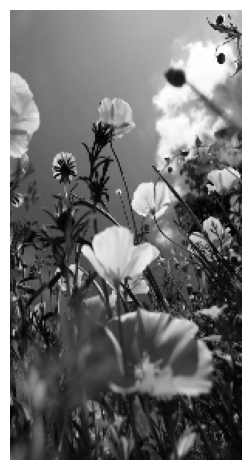

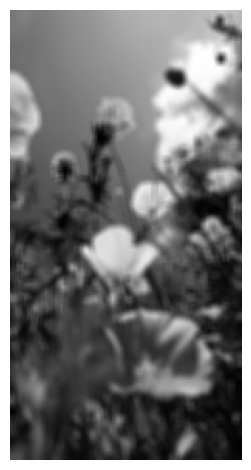

w_init.shape=(292, 150, 20)
theta_initial=np.float64(-15.0)


In [4]:
set_seed(42)

# Load the original image
image = imageio.imread('photos/flower.jpeg', mode="L")  
image = image.astype(np.float64) 

# Reshape the image for computational cost reasons
n1, n2 = int(584 / 2), int(300 / 2)
image = scipy.ndimage.zoom(image, (n1 / image.shape[0], n2 / image.shape[1]), order=1)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

# Generate blurring matrix
H = generate_blur_matrix(n1, n2, patch_size=int(10 / 2))

# Generate observed image (y = Hx + noise)
sigma=0.47

y = H @ image.flatten() + np.random.normal(0, sigma, size=(n1 * n2))
y = y.reshape(n1, n2)

plt.imshow(y, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

# Compute discrete gradient operator
Dx, Dy = discrete_gradient(n1, n2)

N = 20
sigma_init = 10
w_init = np.random.normal(50, sigma_init, size=(n1, n2, N))
method_tv = "dr"  # dr or chambolle-pock

theta_initial = np.random.uniform(-15, 10, size = 1)[0]
theta_initial = np.float64(-15)

print(f"{w_init.shape=}")
print(f"{theta_initial=}")

## Algorithms - MYPGD

In [ ]:
# Note: `mypgd` is inspired from: https://github.com/paulaoak/proximal-ipla/tree/main/image_deblurring. 
# Specifically we ensure the prox term is computed correctly!

def mypgd(
    theta,
    w_init,
    H,
    y,
    sigma,
    lambdaaa,
    Dx,
    Dy,
    original,
    K=1000,
    h=0.01,
    method_tv="dr",
):
    """
    (Correct) MYPGD implementation.
    """
    w = w_init.copy()
    Dw = w.shape[0] * w.shape[1]
    N = w.shape[-1]

    theta_values = np.zeros(K)

    mse_values = np.zeros(K)
    nmse_values = np.zeros(K)
    ssim_values = np.zeros(K)

    mse_mean_image_values = np.zeros(K)
    nmse_mean_image_values = np.zeros(K)
    ssim_mean_image_values = np.zeros(K)

    y_flat = y.flatten()[:, None]

    for k in tqdm(range(K), desc="MYPGD"):
        # Parameter update
        theta = theta - h * (np.exp(theta) * np.mean(total_variation(w, Dx, Dy)) / Dw - 1.0)
        theta_values[k] = theta

        # Particle update
        w_flat = w.reshape(-1, N)
        grad_data = (H.T @ (H @ w_flat - y_flat)) / (sigma ** 2)
        grad_data = np.asarray(grad_data).reshape(w.shape)

        prox_term_w = prox_particles(
            w,
            theta,
            lambdaaa,
            method_tv=method_tv,
            n_jobs=-1,
        )

        z = np.random.normal(0.0, 1.0, w.shape)
        w = (
            w * (1.0 - h / lambdaaa)
            - h * grad_data
            + (h / lambdaaa) * prox_term_w
            + np.sqrt(2.0 * h) * z
        )

        # Logging
        metrics = reconstruction_metrics_unweighted(w, original)

        mse_values[k] = metrics["mse"]
        nmse_values[k] = metrics["nmse"]
        ssim_values[k] = metrics["ssim"]

        mse_mean_image_values[k] = metrics["mse_mean_image"]
        nmse_mean_image_values[k] = metrics["nmse_mean_image"]
        ssim_mean_image_values[k] = metrics["ssim_mean_image"]

    final_metrics = reconstruction_metrics_unweighted(w, original)

    return {
        "samples": w,
        "theta": theta_values,

        # Particle-cloud summaries
        "mse": mse_values,
        "nmse": nmse_values,
        "ssim": ssim_values,

        # Mean-image summaries
        "mse_mean_image": mse_mean_image_values,
        "nmse_mean_image": nmse_mean_image_values,
        "ssim_mean_image": ssim_mean_image_values,

        # Final reconstruction
        "x_hat": final_metrics["x_hat"],
    }

## Algorithms - SOSMC-MYULA

In [ ]:
### SOSMC-MYULA Implementation ###

def data_potential_particles(
    w: np.ndarray,
    H,
    y: np.ndarray,
    sigma: float,
) -> np.ndarray:
    """
    Per-particle Gaussian data potential.
    """
    N = w.shape[2]
    y_flat = y.reshape(-1, 1)
    w_flat = w.reshape(-1, N)

    residual = H @ w_flat - y_flat
    residual = np.asarray(residual)

    return np.sum(residual ** 2, axis=0) / (2.0 * sigma ** 2)


def posterior_potential_particles(
    w: np.ndarray,
    theta: float,
    H,
    y: np.ndarray,
    sigma: float,
    Dx,
    Dy,
    tv_vals: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Per-particle negative log unnormalised target, up to constants.
    """
    if tv_vals is None:
        tv_vals = total_variation_particles(w, Dx, Dy)

    data_vals = data_potential_particles(w, H, y, sigma)
    U_vals = data_vals + np.exp(theta) * tv_vals

    return U_vals, tv_vals


def myula_mean(
    w: np.ndarray,
    theta: float,
    H,
    y: np.ndarray,
    sigma: float,
    lambdaaa: float,
    h_w: float,
    method_tv: str = "dr",
    n_jobs: int = -1,
) -> np.ndarray:
    """
    MYULA proposal mean.
    """
    N = w.shape[2]
    y_flat = y.reshape(-1, 1)
    w_flat = w.reshape(-1, N)

    grad_data = (H.T @ (H @ w_flat - y_flat)) / (sigma ** 2)
    grad_data = np.asarray(grad_data).reshape(w.shape)

    prox_w = prox_particles(
        w,
        theta,
        lambdaaa,
        method_tv=method_tv,
        n_jobs=n_jobs,
    )

    return (
        (1.0 - h_w / lambdaaa) * w
        - h_w * grad_data
        + (h_w / lambdaaa) * prox_w
    )


def log_gaussian_transition_density(
    x_to: np.ndarray,
    mean_from: np.ndarray,
    h_w: float,
) -> np.ndarray:
    """
    Per-particle log Gaussian transition density, dropping constants.
    """
    return -np.sum((x_to - mean_from) ** 2, axis=(0, 1)) / (4.0 * h_w)


def myula_move(
    w: np.ndarray,
    theta: float,
    H,
    y: np.ndarray,
    sigma: float,
    lambdaaa: float,
    h_w: float,
    rng: np.random.Generator,
    Dx,
    Dy,
    log_A: np.ndarray,
    method_tv: str = "dr",
    n_jobs: int = -1,
) -> tuple[np.ndarray, np.ndarray, float]:
    """
    SOSMC-MYULA proposal move with reverse-kernel SMC correction.
    """
    w_old = w

    U_old, _ = posterior_potential_particles(
        w=w_old,
        theta=theta,
        H=H,
        y=y,
        sigma=sigma,
        Dx=Dx,
        Dy=Dy,
    )

    mean_forward = myula_mean(
        w=w_old,
        theta=theta,
        H=H,
        y=y,
        sigma=sigma,
        lambdaaa=lambdaaa,
        h_w=h_w,
        method_tv=method_tv,
        n_jobs=n_jobs,
    )

    w_new = mean_forward + np.sqrt(2.0 * h_w) * rng.normal(size=w_old.shape)

    U_new, _ = posterior_potential_particles(
        w=w_new,
        theta=theta,
        H=H,
        y=y,
        sigma=sigma,
        Dx=Dx,
        Dy=Dy,
    )

    mean_backward = myula_mean(
        w=w_new,
        theta=theta,
        H=H,
        y=y,
        sigma=sigma,
        lambdaaa=lambdaaa,
        h_w=h_w,
        method_tv=method_tv,
        n_jobs=n_jobs,
    )

    log_q_forward = log_gaussian_transition_density(
        x_to=w_new,
        mean_from=mean_forward,
        h_w=h_w,
    )

    log_q_backward = log_gaussian_transition_density(
        x_to=w_old,
        mean_from=mean_backward,
        h_w=h_w,
    )

    delta_move = -U_new + U_old + log_q_backward - log_q_forward

    log_A = log_A + delta_move
    log_A = log_A - np.max(log_A)

    ess_after_move = effective_sample_size_from_logw(log_A)

    return w_new, log_A, ess_after_move


def sosmc_myula(
    theta_init: float,
    w_init: np.ndarray,
    H,
    y: np.ndarray,
    sigma: float,
    lambdaaa: float,
    Dx,
    Dy,
    original: np.ndarray,
    K: int = 500,
    h_theta: float = 0.01,
    h_w: float = 0.01,
    ess_resample_ratio: float = 0.9,
    ess_adapt_ratio: float = 0.95,
    adapt_factor: float = 1.05,
    h_w_min: float = 1e-5,
    h_w_max: float = 0.1,
    rejuvenation_steps: int = 1,
    method_tv: str = "dr",
    seed: int = 0,
    verbose: bool = True,
    n_jobs: int = -1,
) -> dict:
    """
    SOSMC-MYULA implementation.
    """
    rng = np.random.default_rng(seed)

    w = w_init.copy()
    theta = float(theta_init)

    n1, n2, N = w.shape
    Dw = n1 * n2

    log_A = np.zeros(N, dtype=np.float64)

    theta_values = np.zeros(K, dtype=np.float64)

    ess_values = np.zeros(K, dtype=np.float64)
    ess_target_values = np.zeros(K, dtype=np.float64)
    ess_move_values = np.zeros(K, dtype=np.float64)
    h_w_values = np.zeros(K, dtype=np.float64)

    mse_values = np.zeros(K, dtype=np.float64)
    nmse_values = np.zeros(K, dtype=np.float64)
    ssim_values = np.zeros(K, dtype=np.float64)

    mse_mi_values = np.zeros(K, dtype=np.float64)
    nmse_mi_values = np.zeros(K, dtype=np.float64)
    ssim_mi_values = np.zeros(K, dtype=np.float64)

    iterator = tqdm(range(K), desc="SOSMC-MYULA-revK") if verbose else range(K)

    for k in iterator:

        weights = softmax_log_weights(log_A)

        theta_old = float(theta)

        tv_vals = total_variation_particles(w, Dx, Dy)

        grad_per_particle = np.exp(theta_old) * tv_vals / Dw - 1.0
        grad_theta = float(np.sum(weights * grad_per_particle))

        theta = float(theta_old - h_theta * grad_theta)
        theta_values[k] = theta

        delta_exp_theta = np.exp(theta) - np.exp(theta_old)

        log_A = log_A - delta_exp_theta * tv_vals
        log_A = log_A - np.max(log_A)

        ess_target = effective_sample_size_from_logw(log_A)
        ess_target_values[k] = ess_target

        if ess_target < ess_adapt_ratio * N:
            h_w = max(h_w / adapt_factor, h_w_min)
        else:
            h_w = min(h_w * adapt_factor, h_w_max)

        # Enforce MYULA stability h_w < lambdaaa.
        h_w = min(h_w, 0.99 * lambdaaa)
        h_w_values[k] = h_w

        if ess_target < ess_resample_ratio * N:
            weights_r = softmax_log_weights(log_A)
            idx = systematic_resample(weights_r, rng)
            w = w[:, :, idx]
            log_A = np.zeros(N, dtype=np.float64)
            ess_target = float(N)

        ess_move = np.nan

        for _ in range(rejuvenation_steps):
            w, log_A, ess_move = myula_move(
                w=w,
                theta=theta,
                H=H,
                y=y,
                sigma=sigma,
                lambdaaa=lambdaaa,
                h_w=h_w,
                rng=rng,
                Dx=Dx,
                Dy=Dy,
                log_A=log_A,
                method_tv=method_tv,
                n_jobs=n_jobs,
            )

            if ess_move < ess_resample_ratio * N:
                weights_r = softmax_log_weights(log_A)
                idx = systematic_resample(weights_r, rng)
                w = w[:, :, idx]
                log_A = np.zeros(N, dtype=np.float64)
                ess_move = float(N)

        ess_move_values[k] = ess_move
        ess_values[k] = effective_sample_size_from_logw(log_A)

        # Logging
        metrics = reconstruction_metrics_weighted(w, log_A, original)

        mse_values[k] = metrics["mse"]
        nmse_values[k] = metrics["nmse"]
        ssim_values[k] = metrics["ssim"]

        mse_mi_values[k] = metrics["mse_mean_image"]
        nmse_mi_values[k] = metrics["nmse_mean_image"]
        ssim_mi_values[k] = metrics["ssim_mean_image"]

    return {
        "samples": w,
        "theta": theta_values,

        "ess": ess_values,
        "ess_target": ess_target_values,
        "ess_move": ess_move_values,
        "h_w": h_w_values,
        "log_weights": log_A,

        # Particle-cloud summaries
        "mse": mse_values,
        "nmse": nmse_values,
        "ssim": ssim_values,

        # Mean-image summaries
        "mse_mean_image": mse_mi_values,
        "nmse_mean_image": nmse_mi_values,
        "ssim_mean_image": ssim_mi_values,

        # Final reconstruction
        "x_hat": weighted_mean_image(w, log_A),
    }

## Run Experiment

In [ ]:
out_mypgd = mypgd(
    theta=theta_initial,
    w_init=w_init,
    H=H,
    y=y,
    sigma=sigma,
    lambdaaa=0.4,
    Dx=Dx,
    Dy=Dy,
    original=image,
    K=3_000,
    h=0.01,
    method_tv=method_tv,
)


out_sosmc_myula = sosmc_myula(
    theta_init=theta_initial,
    w_init=w_init,
    H=H,
    y=y,
    sigma=sigma,
    Dx=Dx,
    Dy=Dy,
    original=image,
    K=3_000,
    h_theta=0.01,
    h_w=0.01,
    lambdaaa=0.4,
    method_tv=method_tv,
    seed=42,
    h_w_max=0.99,
    h_w_min=0.0001,
    ess_resample_ratio=0.9,
    ess_adapt_ratio = 0.95,
    adapt_factor = 1.01,
)

results = {
    "SOSMC-MYULA": out_sosmc_myula,
    "MYPGD": out_mypgd,
}

plot_results(
    results,
    keys=["theta", "mse", "nmse", "ssim"],
    labels_map={
        "theta": "theta",
        "mse": "Particle-cloud MSE",
        "nmse": "Particle-cloud NMSE",
        "ssim": "Particle-cloud SSIM",
    },
)

fig, axes = plt.subplots(2, 4, figsize=(10, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(out_sosmc_myula['samples'][:, :, i], cmap="gray")
    ax.set_title(f"Particle {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Load Experiment Results

In [5]:
with open("results/setup_B.pkl", "rb") as f:
    saved = pickle.load(f)

results = saved["results"]
out_mypgd = saved["out_mypgd"]
out_sosmc_myula = saved["out_sosmc_myula"]
config = saved["config"]

## Plotting

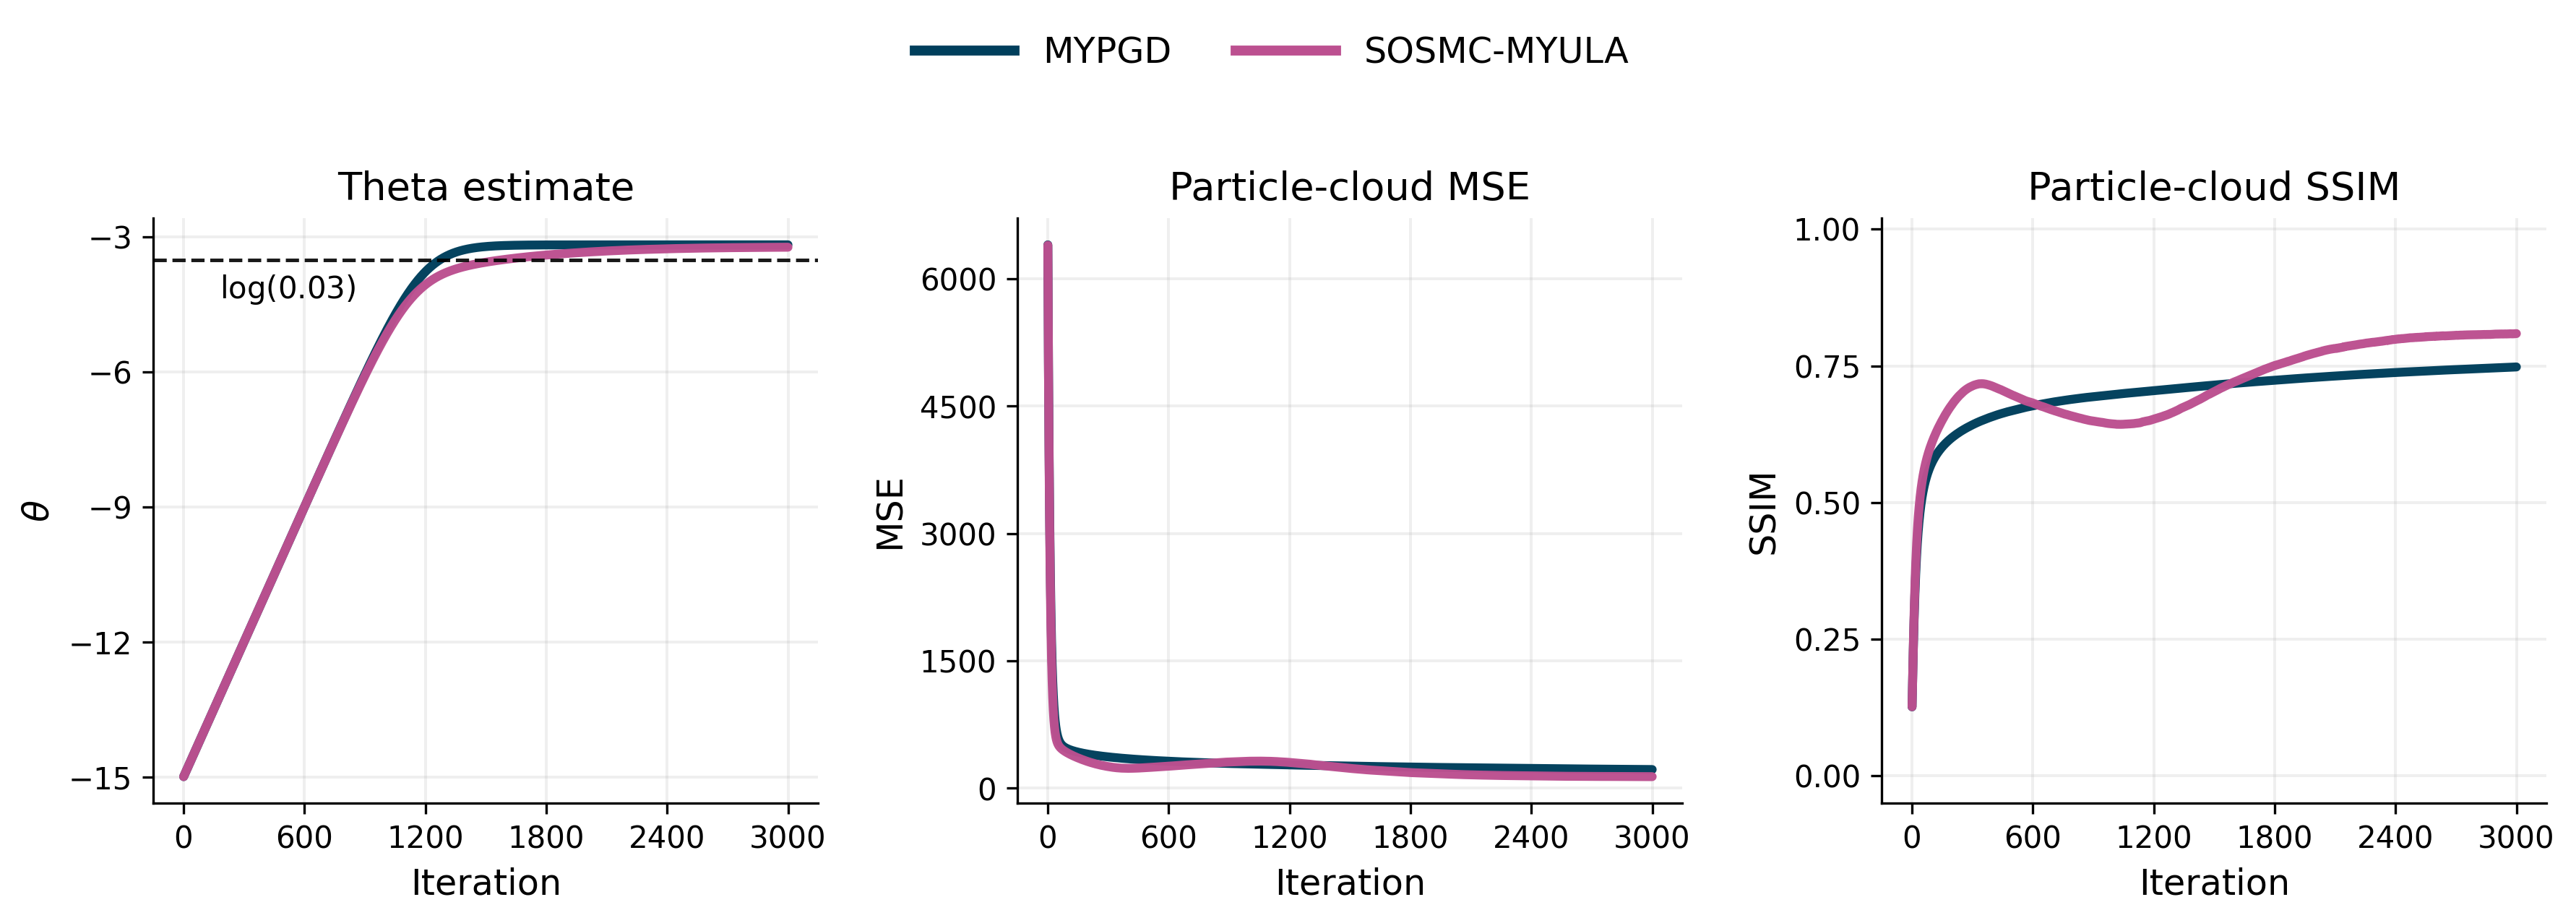

In [6]:
plot_deblurring_metrics_three_panel(
    results,
    methods=("MYPGD", "SOSMC-MYULA"),
    figsize=(12, 4.5),
    dpi=300,
    title="",
    save_path="plots/setup_B/evaluation_curves.pdf",
)

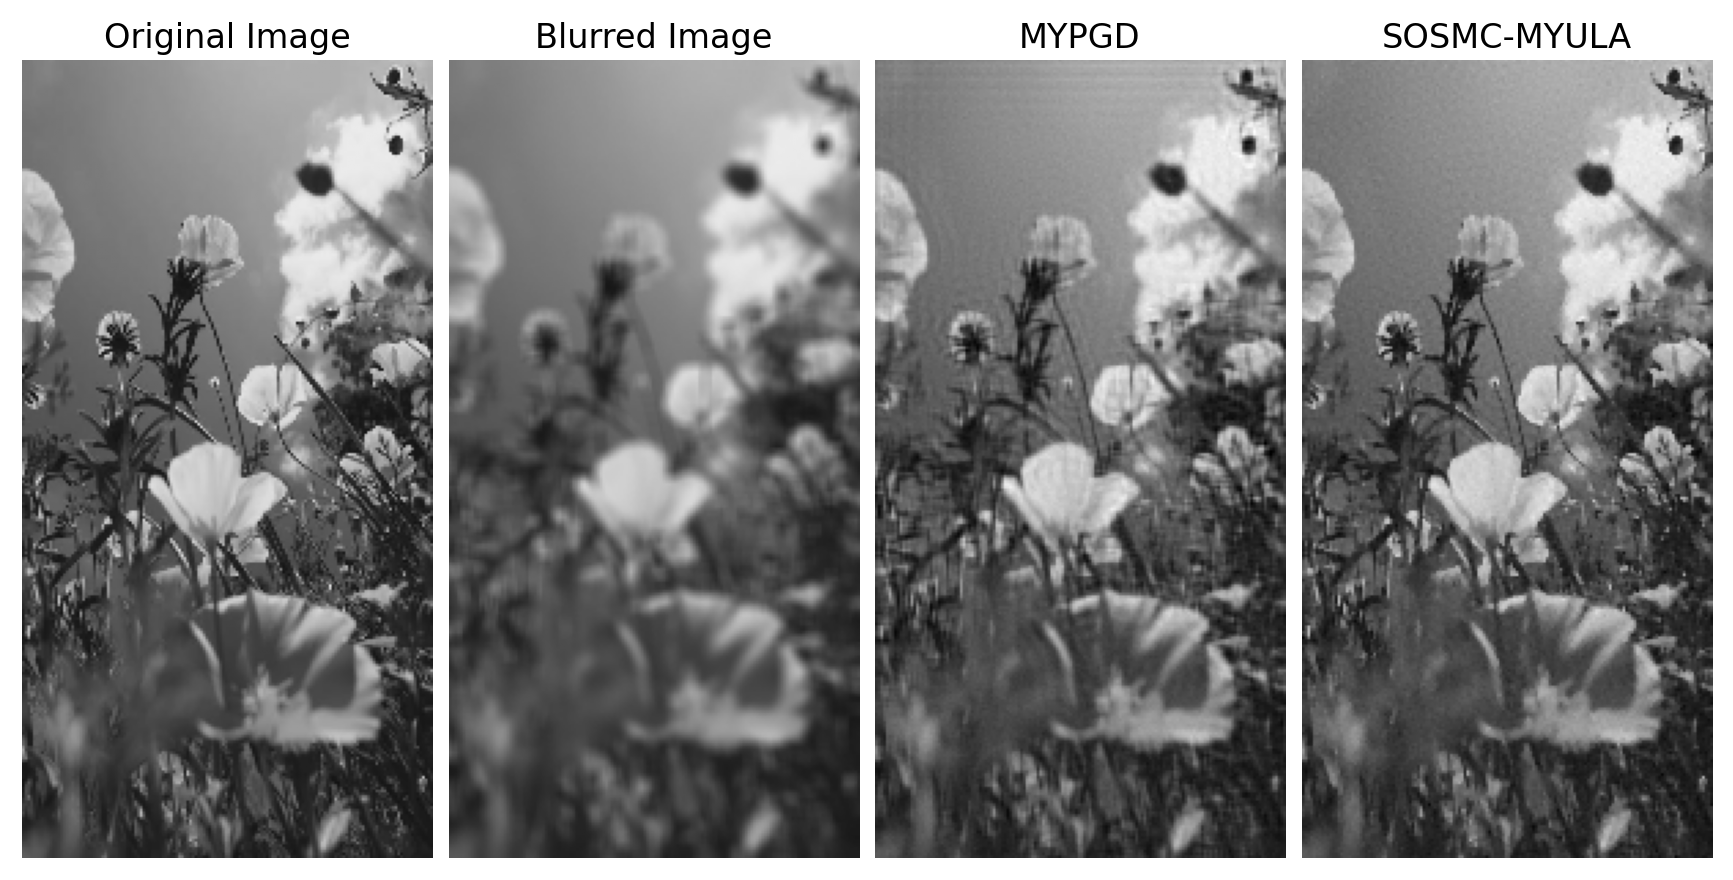

In [7]:
### As in Problem Setup ###

set_seed(42)

# Load the original image
image = imageio.imread('photos/flower.jpeg', mode="L")  
image = image.astype(np.float64) 

# Reshape the image for computational cost reasons
n1, n2 = int(584 / 2), int(300 / 2)
image = scipy.ndimage.zoom(image, (n1 / image.shape[0], n2 / image.shape[1]), order=1)

# Generate blurring matrix
H = generate_blur_matrix(n1, n2, patch_size=int(10 / 2))

# Generate observed image (y = Hx + noise)
sigma=0.47

y = H @ image.flatten() + np.random.normal(0, sigma, size=(n1 * n2))
y = y.reshape(n1, n2)


plot_reconstruction_ordered(
    image,
    y,
    out_mypgd,
    out_sosmc_myula,
    figsize=(8, 7),
    dpi=220,
    save_path="plots/setup_B/images_ordered.pdf",
)

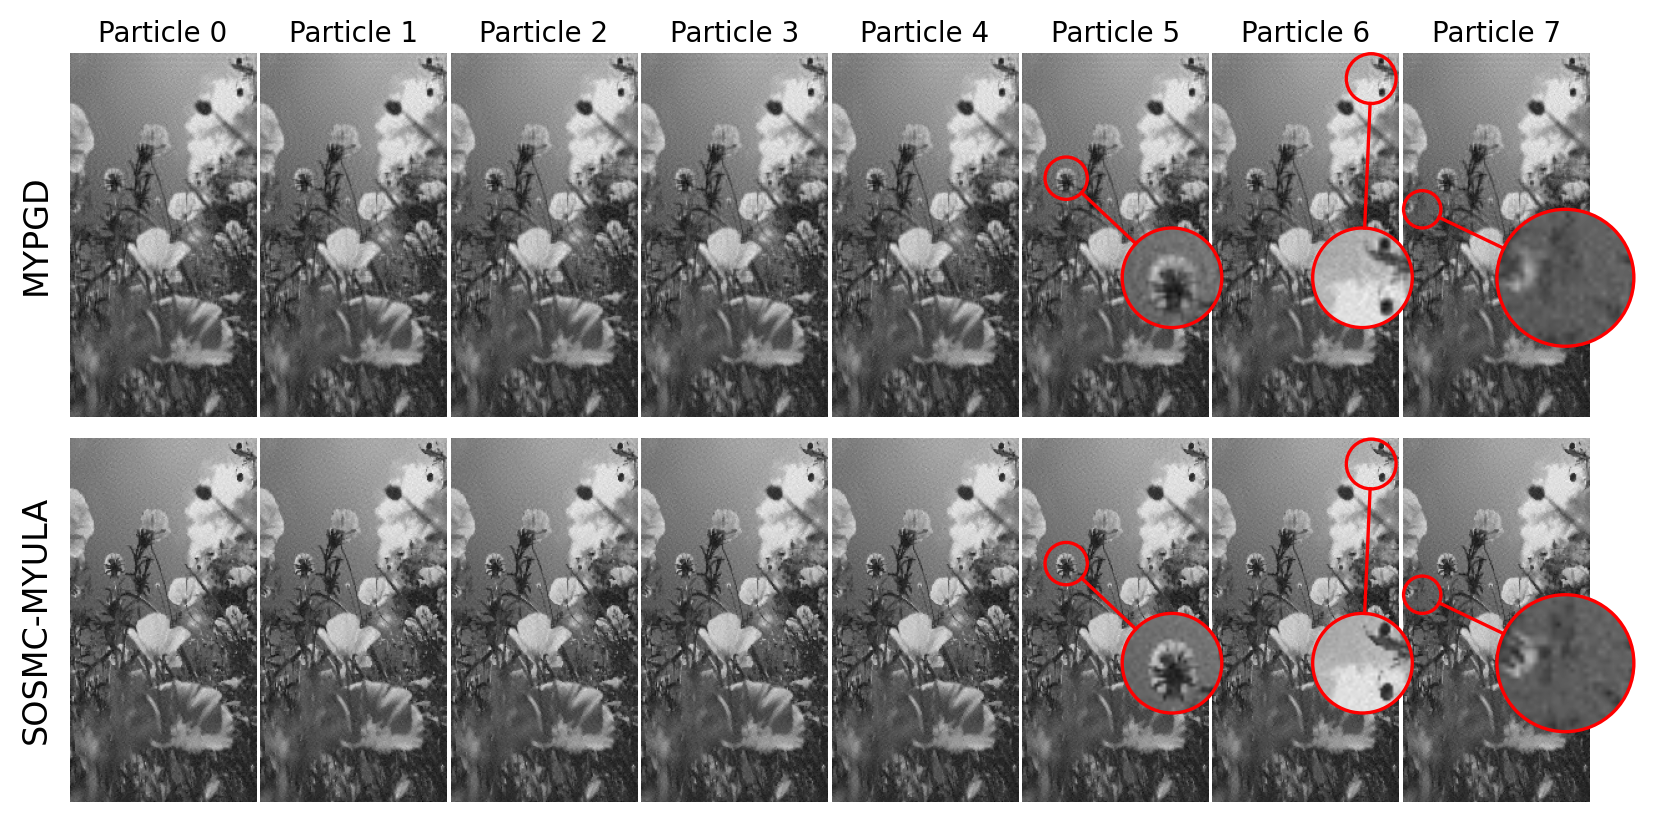

In [8]:
plot_particle_cloud_comparison(
    results,
    methods=("MYPGD", "SOSMC-MYULA"),
    particle_indices=(0, 1, 2, 3, 4, 5, 6, 7),
    figsize=(8, 4.5),
    inspect=True,
    inspect_columns=(5, 6, 7),
    inspect_src_center={5: (35,  100), 6: (127,  20), 7: (15, 125)},
    inspect_src_radius={5: 17,         6: 20,         7: 15},
    inspect_dst_center={5: (120, 180),  6: (120, 180),  7: (130, 180)},
    inspect_dst_radius={5: 40,         6: 40,         7: 55},
    save_path="plots/setup_B/final_particles_comparison.pdf",
)